In [87]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl

In [88]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/fitlered_populations.pkl", "rb") as file:
    filtered_df_original = pkl.load(file)

In [89]:
with open("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/fitlered_populations_LPH12.pkl", "rb") as file:
    LPH12_mgkpro = pkl.load(file)["MgkPro"]

In [90]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols = [name for name in protocol_cols]

In [91]:
original_mgkpro = filtered_df_original["MgkPro"]

In [92]:
original_mgkpro["dataset"] = "Original"

In [93]:
LPH12_mgkpro["dataset"] = "LPH12"

In [94]:
joint_df = pd.concat([original_mgkpro, 
                      LPH12_mgkpro], axis=0)

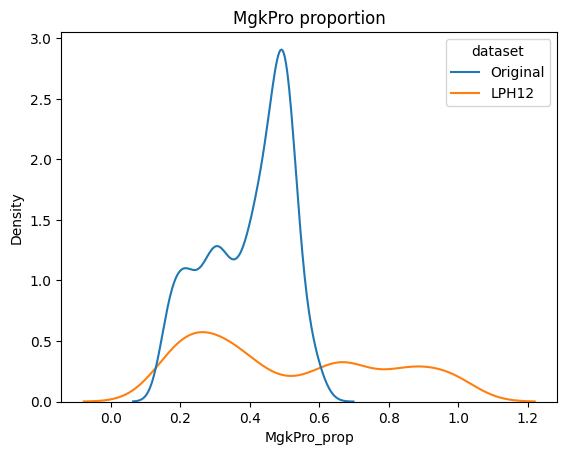

In [106]:
sns.kdeplot(joint_df, x="MgkPro_prop", hue="dataset")
plt.title("MgkPro proportion")
plt.show()

In [96]:
sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

# Distances from sakurai

In [99]:
joint_df["sakurai_dist"] = sp.spatial.distance.cdist(joint_df.loc[:, protocol_cols].values, 
                                                     sakurai_medium[None])

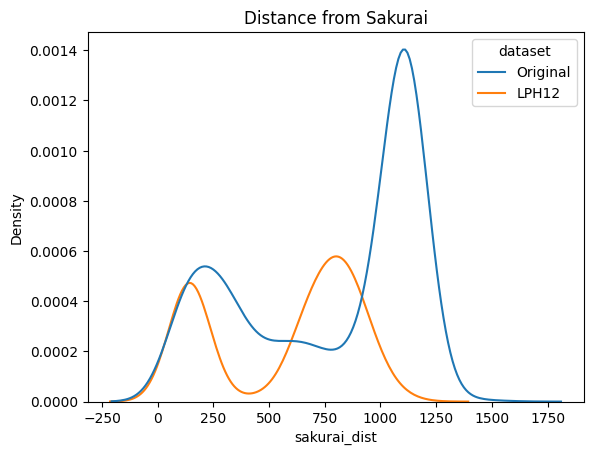

In [105]:
sns.kdeplot(joint_df, x="sakurai_dist", hue="dataset")
plt.title("Distance from Sakurai")
plt.show()